# **Exercise 1 : (all)**

In [1]:
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition
import shutil

## If CBC is not installed, install it
if not shutil.which("cbc"):
  !apt-get install coinor-cbc
else:
  print("CBC is already installed")

# --- Data Definition ---
nodes = ['BOM', 'BEL', 'SOL', 'HUB', 'MAN', 'GUL', 'BAN', 'CHE']
arcs = {
    ('BOM', 'SOL'): 3, ('BOM', 'HUB'): 6,
    ('BEL', 'HUB'): 2, ('BEL', 'MAN'): 3,
    ('SOL', 'GUL'): 4, ('SOL', 'HUB'): 4,
    ('HUB', 'GUL'): 4, ('HUB', 'MAN'): 2, ('HUB', 'BAN'): 4,
    ('MAN', 'BAN'): 3,
    ('GUL', 'CHE'): 7, ('GUL', 'BAN'): 2,
    ('BAN', 'CHE'): 3
}
# Supply is positive, Demand is negative
net_flow = {
    'BOM': 190, 'BEL': 110,
    'CHE': -200, 'BAN': -100,
    'SOL': 0, 'HUB': 0, 'MAN': 0, 'GUL': 0
}

# --- Robust Function to Print Results ---
def print_results(model_name, model, result):
    print(f"\n--- [R] Results for the {model_name} ---")
    if (result.solver.status == SolverStatus.ok) and (result.solver.termination_condition == TerminationCondition.optimal):
        print("✅ Solver found an optimal solution.")
        print(f"Optimal Solution Value (Total Cost): {pyo.value(model.cost):.2f}")
        print("\nFlow in each link (in million barrels):")
        has_flow = False
        for (i, j) in sorted(model.flow.keys()):
            if pyo.value(model.flow[i, j]) > 0.01:
                print(f"  {i} -> {j}: {pyo.value(model.flow[i, j]):.2f}")
                has_flow = True
        if not has_flow:
            print("  No flow detected.")
    elif result.solver.termination_condition == TerminationCondition.infeasible:
        print("❌ Solver Status: Infeasible. The model has no solution.")
    else:
        print(f"Solver Status: {result.solver.status}")
        print(f"Termination Condition: {result.solver.termination_condition}")

# --- Model 1: Initial Problem ---
model1 = pyo.ConcreteModel(name="Initial_Problem")
model1.flow = pyo.Var(arcs.keys(), within=pyo.NonNegativeReals)
model1.cost = pyo.Objective(
    expr=sum(model1.flow[i, j] * arcs[i, j] for (i, j) in arcs.keys()),
    sense=pyo.minimize
)
model1.node_balance = pyo.ConstraintList()
for node in nodes:
    in_flow = sum(model1.flow[i, j] for (i, j) in arcs.keys() if j == node)
    out_flow = sum(model1.flow[i, j] for (i, j) in arcs.keys() if i == node)
    model1.node_balance.add(out_flow - in_flow == net_flow[node])

# --- Model 2: Modified Problem ---
model2 = model1.clone()
model2.name = "Modified_Problem"
model2.sol_gul_disruption = pyo.Constraint(expr=model2.flow['SOL', 'GUL'] == 0)
model2.ban_capacity = pyo.Constraint(
    expr=model2.flow['HUB', 'BAN'] + model2.flow['MAN', 'BAN'] + model2.flow['GUL', 'BAN'] <= 150
)

# --- Solve and Display Results ---
solver = pyo.SolverFactory('cbc',executable='/usr/bin/cbc')
result1 = solver.solve(model1)
print_results(model1.name, model1, result1)

print("\n" + "="*50)

result2 = solver.solve(model2)
print_results(model2.name, model2, result2)

CBC is already installed
ERROR: Unable to clone Pyomo component attribute. Component 'FiniteSetOf'
contains an uncopyable field '_ref' (<class 'dict_keys'>).  Setting field to
`None` on new object

--- [R] Results for the Initial_Problem ---
✅ Solver found an optimal solution.
Optimal Solution Value (Total Cost): 2970.00

Flow in each link (in million barrels):
  BAN -> CHE: 200.00
  BEL -> MAN: 110.00
  BOM -> SOL: 190.00
  GUL -> BAN: 190.00
  MAN -> BAN: 110.00
  SOL -> GUL: 190.00


--- [R] Results for the Modified_Problem ---
✅ Solver found an optimal solution.
Optimal Solution Value (Total Cost): 3760.00

Flow in each link (in million barrels):
  BAN -> CHE: 50.00
  BEL -> HUB: 110.00
  BOM -> HUB: 190.00
  GUL -> CHE: 150.00
  HUB -> BAN: 150.00
  HUB -> GUL: 150.00


# **Exercise 2 : (1)**

In [2]:
import networkx as nx

class Student:
    def __init__(
        self,
        roll,     # string
        name,     # string
        cpi,      # number
        passyear  # number
    ):
        self.roll     = roll
        self.name     = name
        self.cpi      = cpi
        self.passyear = passyear

G = nx.DiGraph()    # Use nx.Graph for an undirected graph

# Create data for nodes
s1 = Student("23m9991", "Akbar", 9.99, 2025)
s2 = Student("23m9992", "Bindu", 10.00, 2026)
s3 = Student("23m9993", "Chatur", 8.69, 2025)
s4 = Student("23m9994", "Dusty", 7.64, 2026)

# Add the nodes in the graph. Each node is identified by the roll number
G.add_node(s1.roll, data=s1)
G.add_node(s2.roll, data=s2)
G.add_node(s3.roll, data=s3)
G.add_node(s4.roll, data=s4)

# Add the edges
G.add_edge(s1.roll, s2.roll)
G.add_edge(s1.roll, s3.roll)
G.add_edge(s1.roll, s4.roll)
G.add_edge(s2.roll, s4.roll)

In [3]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

print("Nodes:")
print(list(G.nodes()))

print("Edges:")
print(list(G.edges()))

Number of nodes: 4
Number of edges: 4
Nodes:
['23m9991', '23m9992', '23m9993', '23m9994']
Edges:
[('23m9991', '23m9992'), ('23m9991', '23m9993'), ('23m9991', '23m9994'), ('23m9992', '23m9994')]


In [4]:
# Access the neighbors of a node

print("Neighbours of 23m9991:")
for v in G.neighbors("23m9991"):
    print(v, G.nodes[v]["data"].name)

Neighbours of 23m9991:
23m9992 Bindu
23m9993 Chatur
23m9994 Dusty


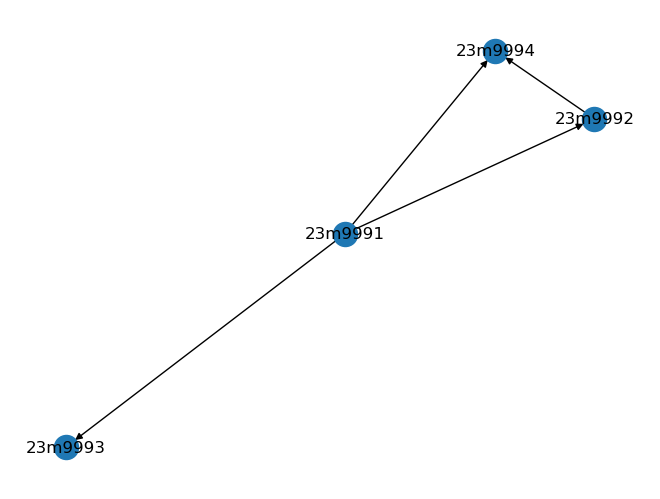

In [5]:
# Finally, draw the graph to visualize it
nx.draw(G, with_labels=True)

# **Exercise 2 : (2)**

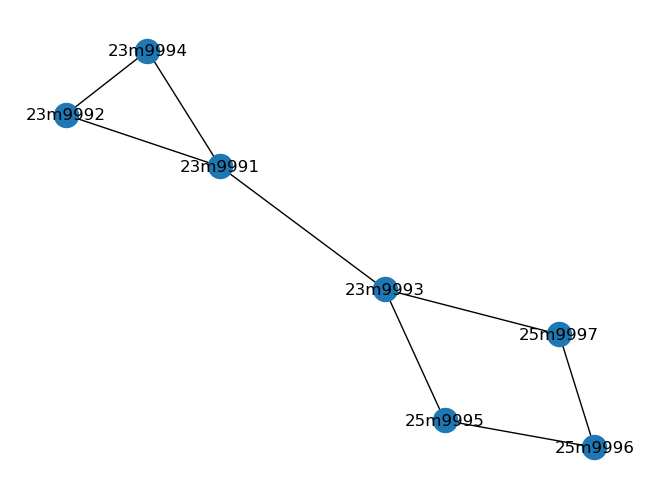

In [6]:
# three new nodes
s5 = Student("25m9995", "Alice", 9.00, 2027)
s6 = Student("25m9996", "Bob", 9.01, 2027)
s7 = Student("25m9997", "Charlie", 9.02, 2027)

# Add the nodes in the graph. Each node is identified by the roll number
G.add_node(s5.roll, data=s5)  
G.add_node(s6.roll, data=s6)
G.add_node(s7.roll, data=s7)

# Add the edges
G.add_edge(s5.roll, s6.roll)
G.add_edge(s6.roll, s7.roll)
G.add_edge(s3.roll, s5.roll)
G.add_edge(s7.roll, s3.roll)

G_undirected = G.to_undirected()

# Finally, redraw the graph to visualize it
nx.draw(G_undirected, with_labels=True)

# **Exercise 2 : (3)**

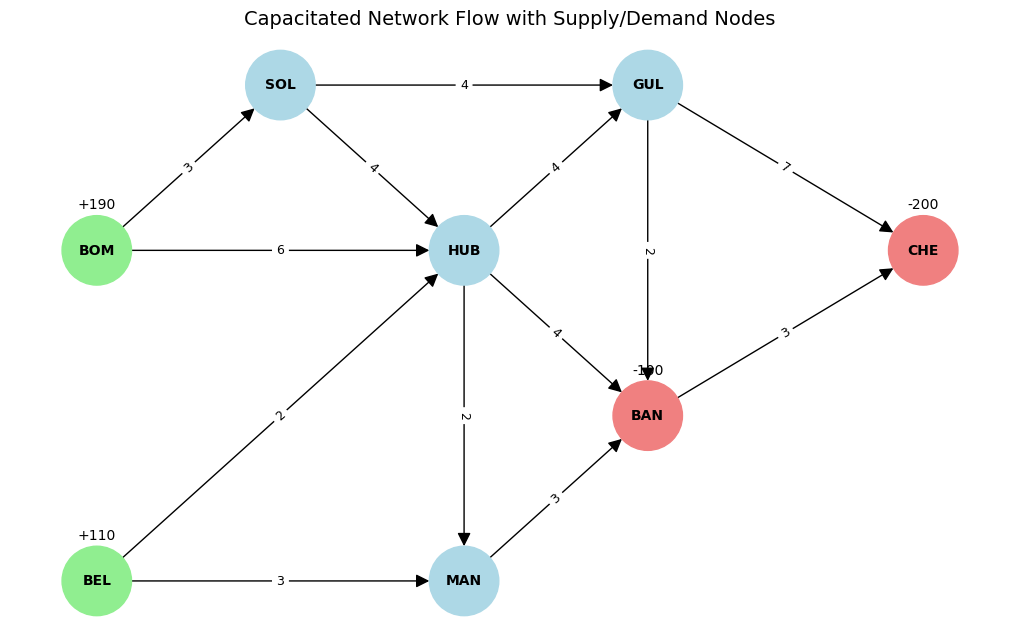

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

# Directed graph
G = nx.DiGraph()

# Edge list with capacities
edges = [
    ('BOM', 'SOL', 3),
    ('BOM', 'HUB', 6),
    ('SOL', 'HUB', 4),
    ('SOL', 'GUL', 4),
    ('HUB', 'GUL', 4),
    ('HUB', 'BAN', 4),
    ('HUB', 'MAN', 2),
    ('BEL', 'HUB', 2),
    ('BEL', 'MAN', 3),
    ('MAN', 'BAN', 3),
    ('GUL', 'CHE', 7),
    ('GUL', 'BAN', 2),
    ('BAN', 'CHE', 3)
]
G.add_weighted_edges_from(edges)

# Node positions roughly matching the original layout
pos = {
    'BOM': (-3, 1),
    'SOL': (-2, 2),
    'HUB': (-1, 1),
    'GUL': (0, 2),
    'BAN': (0, 0),
    'CHE': (1.5, 1),
    'BEL': (-3, -1),
    'MAN': (-1, -1)
}

# Supply (+), demand (-), and transshipment (0)
node_capacity = {
    'BOM': 190,
    'BEL': 110,
    'CHE': -200,
    'BAN': -100,
    'SOL': 0,
    'HUB': 0,
    'MAN': 0,
    'GUL': 0
}

# Assign colors based on capacity
node_colors = []
for n in G.nodes():
    if node_capacity[n] > 0:
        node_colors.append('lightgreen')  # supply
    elif node_capacity[n] < 0:
        node_colors.append('lightcoral')  # demand
    else:
        node_colors.append('lightblue')   # transshipment

# Draw the network
plt.figure(figsize=(10, 6))
nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=2500,
    arrowsize=20,
    font_size=10,
    font_weight='bold'
)

# Draw edge labels (capacities)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=9)

# Annotate node capacities directly
for node, (x, y) in pos.items():
    cap = node_capacity[node]
    if cap != 0:
        plt.text(x, y + 0.25, f"{cap:+}", fontsize=10, color='black', ha='center')

plt.title("Capacitated Network Flow with Supply/Demand Nodes", fontsize=14)
plt.axis('off')
plt.show()


# **Exercise 3 : (1,2)**

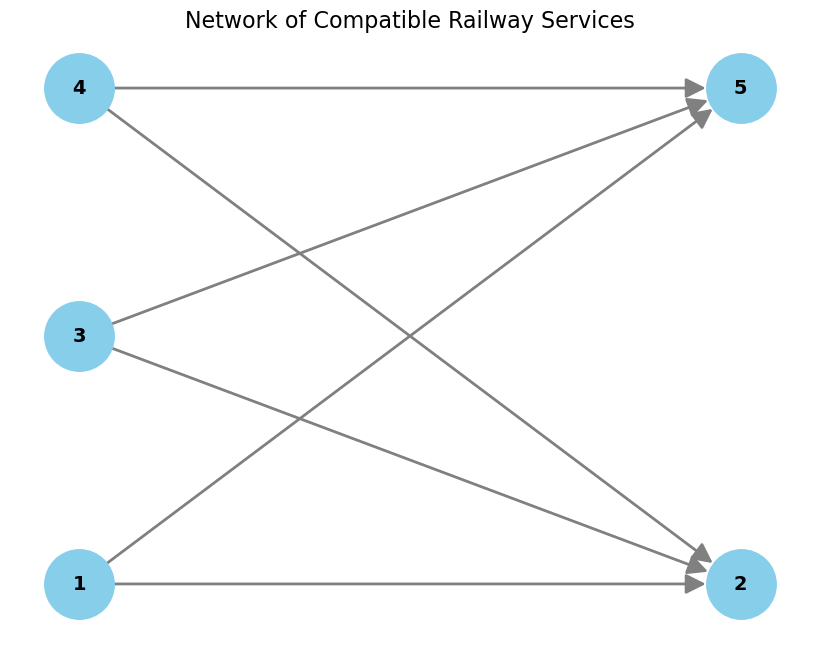

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create a directed graph object
G = nx.DiGraph()

# 2. Add the 5 services as nodes
nodes = [1, 2, 3, 4, 5]
G.add_nodes_from(nodes)

# 3. Add the directed edges based on the logic
# An edge from u to v means service v can be done after service u.
edges = [
    (1, 2), (1, 5),
    (3, 2), (3, 5),
    (4, 2), (4, 5)
]
G.add_edges_from(edges)

# 4. Define a layout for visualization
# We can use a bipartite layout to clearly separate starting and ending services
pos = nx.bipartite_layout(G, nodes=[1, 3, 4])

# 5. Draw and display the graph
plt.figure(figsize=(8, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='skyblue',
    node_size=2500,
    font_size=14,
    font_weight='bold',
    width=2,
    edge_color='gray',
    arrowsize=30,
    arrows=True
)

plt.title("Network of Compatible Railway Services", size=16)
plt.show()

# **Exercise 3 : (3,4)**

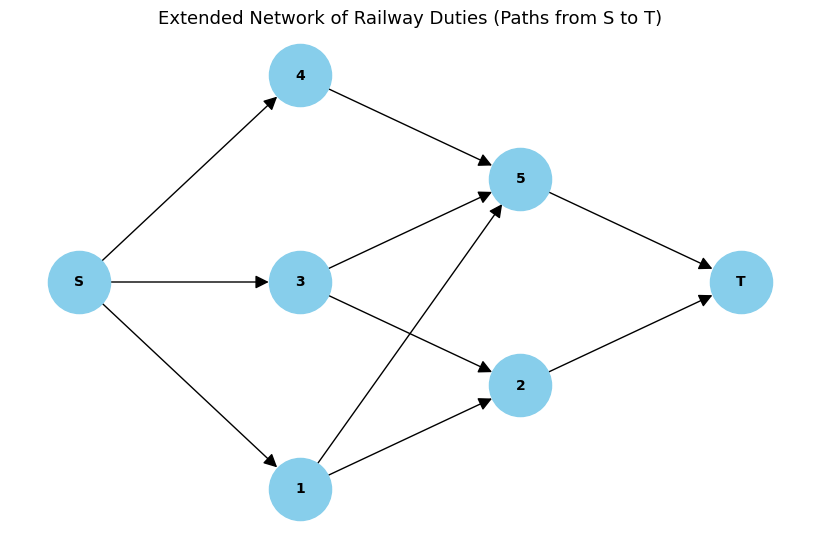

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

# Original network of compatible railway services
G = nx.DiGraph()

# Existing nodes and edges
edges = [
    (1, 2), (1, 5),
    (3, 2), (3, 5),
    (4, 5)
]
G.add_edges_from(edges)

# Add source (S) and sink (T)
G.add_node('S')
G.add_node('T')

# Add edges from source to all service nodes
for node in [1, 3, 4]:
    G.add_edge('S', node)

# Add edges from all service nodes to sink
for node in [2, 5]:
    G.add_edge(node, 'T')

# Layout: left for S, right for T, middle for service nodes
pos = {
    'S': (-1, 0),
    1: (0, -1),
    3: (0, 0),
    4: (0, 1),
    2: (1, -0.5),
    5: (1, 0.5),
    'T': (2, 0)
}

# Draw graph
plt.figure(figsize=(8, 5))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2000,
    node_color='skyblue',
    arrowsize=20,
    font_size=10,
    font_weight='bold'
)

plt.title("Extended Network of Railway Duties (Paths from S to T)", fontsize=13)
plt.axis('off')
plt.show()


# **Exercise 3 : (5,6)**

In [20]:
import pandas as pd
import networkx as nx
import re

# --- Part 5: Constructing the Graph from a CSV file ---

csv_filename = 'large.csv'

try:
    # Read the data directly from the CSV file
    df = pd.read_csv(csv_filename)
    print(f"Successfully loaded {len(df)} records from '{csv_filename}'.")

    # Helper function to convert time strings to total minutes
    def time_to_minutes(time_str):
        time_str = str(time_str)
        parts = list(map(int, re.split(':', time_str)))
        if len(parts) == 3:
            return parts[0] * 60 + parts[1]
        return parts[0] * 60 + parts[1]

    # Helper function to normalize station names
    def normalize_station(name):
        name = str(name)
        suffixes_to_remove = [' UP', ' DN', ' 3RD', ' PF', ' SDG']
        for suffix in suffixes_to_remove:
            name = name.replace(suffix, '')
        return name.strip()

    # --- Process Data and Build Graph ---
    df['Service'] = df['Service'].astype(int)
    df['Start Station Norm'] = df['Start Station'].apply(normalize_station)
    df['End Station Norm'] = df['End Station'].apply(normalize_station)
    df['Start Minutes'] = df['Start Time'].apply(time_to_minutes)
    df['End Minutes'] = df['End Time'].apply(time_to_minutes)

    G_crew = nx.DiGraph()
    for index, row in df.iterrows():
        G_crew.add_node(row['Service'], **row.to_dict())

    for i, row1 in df.iterrows():
        for j, row2 in df.iterrows():
            if i == j: continue
            if (row1['End Station Norm'] == row2['Start Station Norm']) and \
               (row2['Start Minutes'] > row1['End Minutes']):
                G_crew.add_edge(row1['Service'], row2['Service'])

    print(f"Graph constructed with {G_crew.number_of_nodes()} nodes and {G_crew.number_of_edges()} edges.")

    # --- Part 6: Finding Two Non-Intersecting Duties (Optimized) ---

    def find_first_valid_path(graph, start_node, min_length=5):
        """
        Efficiently finds the FIRST valid path of a minimum length from a start node.
        This is much faster than finding the absolute longest path.
        """
        stack = [(start_node, [start_node])]  # (current_node, path_to_current_node)
        while stack:
            current_node, path = stack.pop()

            # If we find a valid path, return it immediately
            if len(path) >= min_length:
                return path

            # Continue searching deeper
            for neighbor in reversed(list(graph.successors(current_node))):
                if neighbor not in path:
                    new_path = path + [neighbor]
                    stack.append((neighbor, new_path))
        return None # No path of required length found from this start node

    found_duties = []
    nodes_in_found_duties = set()

    # Prioritize starting from nodes that are true beginnings of a duty
    start_nodes = [n for n in G_crew.nodes() if G_crew.in_degree(n) == 0]

    # Find two duties
    for node in start_nodes:
        if node not in nodes_in_found_duties:
            # Create a temporary graph view excluding already used nodes
            available_nodes = [n for n in G_crew.nodes() if n not in nodes_in_found_duties]
            subgraph = G_crew.subgraph(available_nodes)

            path = find_first_valid_path(subgraph, node, min_length=5)

            if path:
                found_duties.append(path)
                nodes_in_found_duties.update(path) # Mark these nodes as used

            if len(found_duties) == 2:
                break # Stop once we have found two duties

    # --- Report the Results ---
    print("\n[R] Found two non-intersecting duties with at least 5 services:")
    if len(found_duties) >= 2:
        for i, duty in enumerate(found_duties):
            print(f"\nDuty {i+1} (Path of {len(duty)} services):")
            print(" -> ".join(map(str, duty)))
            first_service = G_crew.nodes[duty[0]]
            last_service = G_crew.nodes[duty[-1]]
            print(f"  Starts: Service {duty[0]} at {first_service['Start Time']} from {first_service['Start Station']}")
            print(f"  Ends:   Service {duty[-1]} at {last_service['End Time']} at {last_service['End Station']}")
    else:
        print("\nCould not find two non-intersecting duties of the required length.")

except FileNotFoundError:
    print(f"❌ Error: The file '{csv_filename}' was not found.")
    print("Please make sure you have uploaded the file and that the filename variable is correct.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded 708 records from 'large.csv'.
Graph constructed with 708 nodes and 106405 edges.

[R] Found two non-intersecting duties with at least 5 services:

Duty 1 (Path of 5 services):
11 -> 20 -> 40 -> 68 -> 96
  Starts: Service 11 at 05:40 from VND
  Ends:   Service 96 at 10:52 at KKDA DN

Duty 2 (Path of 5 services):
377 -> 21 -> 41 -> 69 -> 97
  Starts: Service 377 at 05:40 from MKPD
  Ends:   Service 97 at 10:53 at PVGW UP
